In [1]:
import mpmath as mp
import numpy as np

import matplotlib.pyplot as plt
import time

In [2]:
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 12,
    'axes.grid': True, 
    'xtick.top': True,
    'ytick.right': True,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'grid.alpha': 0.6
})

In [3]:
mp.mp.dps = 2000  # Set decimal places for mpmath

def norm2(v: mp.matrix) -> mp.mpf:
    """Squared 2-norm of a vector (mpmath column matrix)."""
    return mp.fsum([vi**2 for vi in v])


def newton(
    F,
    x0,
    *,
    tol: mp.mpf = mp.mpf("1e-100"),
    max_iter: int = 25,
):
    
    x = x0.copy()

    Fx, Jx = F(x)

    residuals: list[mp.mpf] = []
    errors: list[mp.mpf] = []
    for _ in range(max_iter):

        delta = mp.lu_solve(Jx, Fx)
        errors.append(mp.norm(delta))

        x = x - delta

        Fx, Jx = F(x)
        residuals.append(mp.norm(Fx))
        
        if residuals[-1] < tol:
            return x, residuals, errors

    raise RuntimeError(
        "Newton solver failed after "
        f"{max_iter} iterations; residual={float(residuals[-1]):.3e}"
    )


def KLAM(
    F,
    x0,
    *,
    lamb: mp.mpf = mp.mpf("-5.0"),
    tol: mp.mpf = mp.mpf("1e-100"),
    max_iter: int = 25,
):

    x = x0.copy()
    
    Fx, Jx = F(x)

    residuals: list[mp.mpf] = []
    errors: list[mp.mpf] = []
    for _ in range(max_iter):

        Jx, p = mp.LU_decomp(Jx)
        b = mp.L_solve(Jx, Fx, p)
        Jx_inv_Fx = mp.U_solve(Jx, b)
        
        y = x - Jx_inv_Fx

        Fy, _ = F(y)

        v = norm2(Fy) / norm2(Fx)
        K = 1.0 / (1.0 + lamb * v)

        b = mp.L_solve(Jx, Fy + 2.0 * v * Fx, p)
        delta = mp.U_solve(Jx, b)
        x_new = y - K * delta

        errors.append(mp.norm(x_new - x))
        x = x_new

        Fx, Jx = F(x)
        residuals.append(mp.norm(Fx))

        if residuals[-1] < tol:
            return x, residuals, errors

    raise RuntimeError(
        "KLAM solver failed after "
        f"{max_iter} iterations; residual={float(residuals[-1]):.3e}"
    )


def super_ostrowski(
    F,
    x0,
    *,
    m: int = 4,
    tol: mp.mpf = mp.mpf("1e-100"),
    max_iter: int = 25,
):
    if m < 2:
        raise ValueError(f"The Super-Ostrowski scheme requires at least m=2 steps. Got m={m}")

    x = x0.copy()
    
    Fx, Jx = F(x)

    residuals: list[mp.mpf] = []
    errors: list[mp.mpf] = []

    for _ in range(max_iter):

        Jx, p = mp.LU_decomp(Jx)
        b = mp.L_solve(Jx, Fx, p)
        delta_1 = mp.U_solve(Jx, b)

        S = x - delta_1

        FS, _ = F(S)

        num = 2.0 * mp.fdot(Fx, FS)
        den = mp.fdot(Fx, Fx)
        alpha_k = 1.0 - (num / den)

        for i in range(2, m + 1):
            b = mp.L_solve(Jx, FS, p)
            delta_i = mp.U_solve(Jx, b) / alpha_k
        
            S = S - delta_i

            if i < m:
                FS, _ = F(S)

        errors.append(mp.norm(x - S))
        x = S

        Fx, Jx = F(x)
        residuals.append(mp.norm(Fx))


        if residuals[-1] < tol:
            return x, residuals, errors

    raise RuntimeError(
        "Super-Ostrowski solver failed after "
        f"{max_iter} iterations; residual={float(residuals[-1]):.3e}"
    )

def log10_series(series):
    return [mp.log10(s) for s in series]

def printn(n):
    return f"{n:.2e}".replace("e", "\\times 10^{") + "}"

C:\Users\pedro\AppData\Local\Temp\ipykernel_3780\3289467657.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels(["$10^{" + str(int(e)) + "}$" for e in tick])


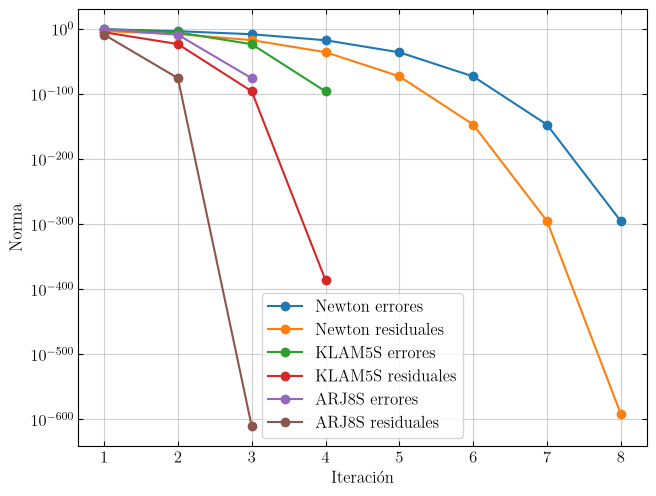

In [4]:
def F(x):
    x1, x2 = x

    Fx = mp.matrix([
        [mp.exp(-x1**2) - mp.sin(x2)],
        [-mp.sin(x1) + mp.exp(-x2**2)]
    ])

    J = mp.matrix([
        [-2 * x1 * mp.exp(-x1**2), -mp.cos(x2)],
        [-mp.cos(x1), -2 * x2 * mp.exp(-x2**2)]
    ])

    return Fx, J


x0 = mp.matrix([
    [mp.mpf("0.5")],
    [mp.mpf("0.5")]
])

time_newton = []
time_klam = []
time_ost = []

for i in range(50):
    t1 = time.time()
    x1, resid1, err1 = newton(F, x0,  tol=mp.mpf("1e-300"))
    t2 = time.time()

    x2, resid2, err2 = KLAM(F, x0, tol=mp.mpf("1e-300"))
    t3 = time.time()

    x3, resid3, err3 = super_ostrowski(F, x0, tol=mp.mpf("1e-300"))
    t4 = time.time()

    time_newton.append(t2 - t1)
    time_klam.append(t3 - t2)
    time_ost.append(t4 - t3)

fig, ax = plt.subplots()

ax.plot(range(1,len(err1)+1), log10_series(err1), '-o', label="Newton errores")
ax.plot(range(1,len(resid1)+1), log10_series(resid1), '-o', label="Newton residuales")

ax.plot(range(1,len(err2)+1), log10_series(err2), '-o', label="KLAM5S errores")
ax.plot(range(1,len(resid2)+1), log10_series(resid2), '-o', label="KLAM5S residuales")

ax.plot(range(1,len(err3)+1), log10_series(err3), '-o', label="ARJ8S errores")
ax.plot(range(1,len(resid3)+1), log10_series(resid3), '-o', label="ARJ8S residuales")

ax.set_ylabel("Norma")


tick = ax.get_yticks()
ax.set_yticklabels(["$10^{" + str(int(e)) + "}$" for e in tick])

ax.set_xlabel("Iteración")
ax.legend()

plt.tight_layout(pad=0.1)
plt.savefig("errores1.pdf", dpi=300)
plt.show()

In [5]:
acoc1 = mp.log(err1[-1] / err1[-2]) / mp.log(err1[-2] / err1[-3])
acoc2 = mp.log(err2[-1] / err2[-2]) / mp.log(err2[-2] / err2[-3])
acoc3 = mp.log(err3[-1] / err3[-2]) / mp.log(err3[-2] / err3[-3])

p1 = [
    r"\textbf{Prob. 1} && \multicolumn{1}{l}{$\mathbf{m=2}$} &&& \\",
    f"    & Newton &   ${len(err1)}$   &   ${printn(err1[-1])}$    &    ${printn(resid1[-1])}$     &   ${acoc1:.2f}$   &    ${np.mean(time_newton):.2f} \\pm {np.std(time_newton):.2f}$ \\\\","\n",
    f"    & KLAM5S &   ${len(err2)}$   &   ${printn(err2[-1])}$    &    ${printn(resid2[-1])}$     &   ${acoc2:.2f}$   &    ${np.mean(time_klam):.2f}   \\pm {np.std(time_klam):.2f}$   \\\\""\n",
    f"    & ARJ8S &    ${len(err3)}$   &   ${printn(err3[-1])}$    &    ${printn(resid3[-1])}$     &   ${acoc3:.2f}$   &    ${np.mean(time_ost):.2f}    \\pm {np.std(time_ost):.2f}$    \\\\""\n",
]

C:\Users\pedro\AppData\Local\Temp\ipykernel_3780\3911903727.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels(["$10^{" + str(int(e)) + "}$" for e in tick])


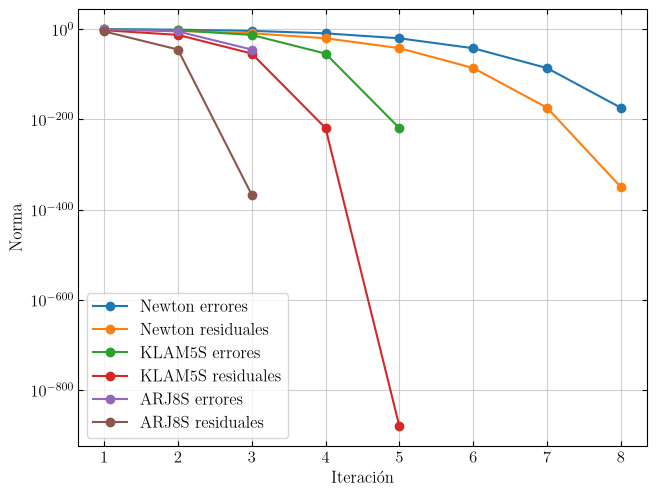

In [6]:
n = 10

def G(x):

    # Function values
    Fx = mp.matrix(n, 1)
    for i in range(n - 1):
        Fx[i] = x[i] * mp.sin(x[i + 1]) - 1
    Fx[n - 1] = x[n - 1] * mp.sin(x[0]) - 1

    # Jacobian
    J = mp.matrix(n, n)

    for i in range(n - 1):
        J[i, i] = mp.sin(x[i + 1])
        J[i, i + 1] = x[i] * mp.cos(x[i + 1])

    J[n - 1, 0] = x[n - 1] * mp.cos(x[0])
    J[n - 1, n - 1] = mp.sin(x[0])

    return Fx, J

x0 = mp.mpf('0.75') * mp.ones(n,1)

time_newton = []
time_klam = []
time_ost = []

for i in range(50):
    t1 = time.time()
    x1, resid1, err1 = newton(G, x0,  tol=mp.mpf("1e-300"), max_iter=500)
    t2 = time.time()

    x2, resid2, err2 =   KLAM(G, x0, tol=mp.mpf("1e-300"), max_iter=500)
    t3 = time.time()

    x3, resid3, err3 = super_ostrowski(G, x0, tol=mp.mpf("1e-300"),  max_iter=500)
    t4 = time.time()

    time_newton.append(t2 - t1)
    time_klam.append(t3 - t2)
    time_ost.append(t4 - t3)
    

fig, ax = plt.subplots()

ax.plot(range(1,len(err1)+1), log10_series(err1), '-o', label="Newton errores")
ax.plot(range(1,len(resid1)+1), log10_series(resid1), '-o', label="Newton residuales")

ax.plot(range(1,len(err2)+1), log10_series(err2), '-o', label="KLAM5S errores")
ax.plot(range(1,len(resid2)+1), log10_series(resid2), '-o', label="KLAM5S residuales")

ax.plot(range(1,len(err3)+1), log10_series(err3), '-o', label="ARJ8S errores")
ax.plot(range(1,len(resid3)+1), log10_series(resid3), '-o', label="ARJ8S residuales")

ax.set_ylabel("Norma")

#ax.set_aspect(7/1800)


tick = ax.get_yticks()
ax.set_yticklabels(["$10^{" + str(int(e)) + "}$" for e in tick])

ax.set_xlabel("Iteración")
ax.legend()

plt.tight_layout(pad=0.1)
plt.savefig("errores2.pdf", dpi=300)
plt.show()

In [7]:
acoc1 = mp.log(err1[-1] / err1[-2]) / mp.log(err1[-2] / err1[-3])
acoc2 = mp.log(err2[-1] / err2[-2]) / mp.log(err2[-2] / err2[-3])
acoc3 = mp.log(err3[-1] / err3[-2]) / mp.log(err3[-2] / err3[-3])

p2 = [
    r"\textbf{Prob. 2} && \multicolumn{1}{l}{$\mathbf{m=10}$} &&& \\",
    f"    & Newton &   ${len(err1)}$   &   ${printn(err1[-1])}$    &    ${printn(resid1[-1])}$     &   ${acoc1:.2f}$   &    ${np.mean(time_newton):.2f} \\pm {np.std(time_newton):.2f}$ \\\\","\n",
    f"    & KLAM5S &   ${len(err2)}$   &   ${printn(err2[-1])}$    &    ${printn(resid2[-1])}$     &   ${acoc2:.2f}$   &    ${np.mean(time_klam):.2f}   \\pm {np.std(time_klam):.2f}$   \\\\""\n",
    f"    & ARJ8S &    ${len(err3)}$   &   ${printn(err3[-1])}$    &    ${printn(resid3[-1])}$     &   ${acoc3:.2f}$   &    ${np.mean(time_ost):.2f}    \\pm {np.std(time_ost):.2f}$    \\\\""\n",
]

C:\Users\pedro\AppData\Local\Temp\ipykernel_3780\4200793681.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels(["$10^{" + str(int(e)) + "}$" for e in tick])


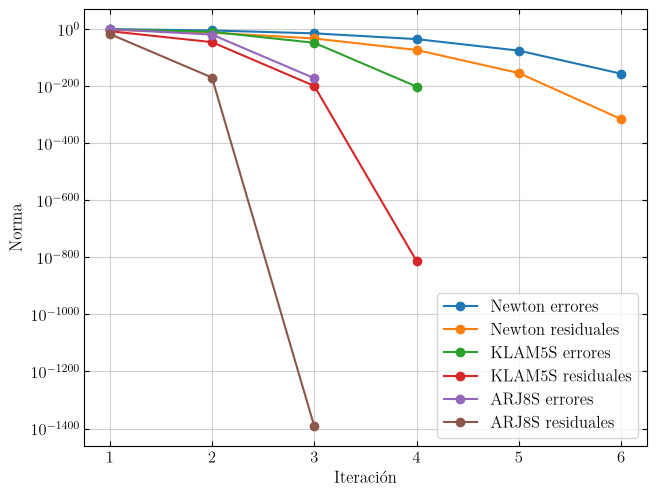

In [8]:
n = 100
def H(x):
    s = mp.fsum(x)

    # Function values
    Fx = mp.matrix([
        mp.atan(x[i]) + 1 - 2*(s - x[i])
        for i in range(n)
    ])

    # Jacobian
    J = mp.matrix(n, n)
    for i in range(n):
        for j in range(n):
            if i == j:
                J[i, j] = 1 / (1 + x[i]**2)
            else:
                J[i, j] = -2

    return Fx, J



x0 = mp.mpf('0.1') * mp.ones(n, 1)


time_newton = []
time_klam = []
time_ost = []

for i in range(50):
    t1 = time.time()
    x1, resid1, err1 = newton(H, x0,  tol=mp.mpf("1e-300"), max_iter=500)
    t2 = time.time()

    x2, resid2, err2 = KLAM(H, x0, tol=mp.mpf("1e-300"), max_iter=500)
    t3 = time.time()

    x3, resid3, err3 = super_ostrowski(H, x0, tol=mp.mpf("1e-300"), max_iter=500)
    t4 = time.time()

    time_newton.append(t2 - t1)
    time_klam.append(t3 - t2)
    time_ost.append(t4 - t3)

fig, ax = plt.subplots()

ax.plot(range(1,len(err1)+1), log10_series(err1), '-o', label="Newton errores")
ax.plot(range(1,len(resid1)+1), log10_series(resid1), '-o', label="Newton residuales")

ax.plot(range(1,len(err2)+1), log10_series(err2), '-o', label="KLAM5S errores")
ax.plot(range(1,len(resid2)+1), log10_series(resid2), '-o', label="KLAM5S residuales")

ax.plot(range(1,len(err3)+1), log10_series(err3), '-o', label="ARJ8S errores")
ax.plot(range(1,len(resid3)+1), log10_series(resid3), '-o', label="ARJ8S residuales")

ax.set_ylabel("Norma")

#ax.set_aspect(7/1800)

tick = ax.get_yticks()
ax.set_yticklabels(["$10^{" + str(int(e)) + "}$" for e in tick])

ax.set_xlabel("Iteración")
ax.legend()

plt.tight_layout(pad=0.1)
plt.savefig("errores3.pdf", dpi=300)
plt.show()

In [9]:
acoc1 = mp.log(err1[-1] / err1[-2]) / mp.log(err1[-2] / err1[-3])
acoc2 = mp.log(err2[-1] / err2[-2]) / mp.log(err2[-2] / err2[-3])
acoc3 = mp.log(err3[-1] / err3[-2]) / mp.log(err3[-2] / err3[-3])

p3 = [
    r"\textbf{Prob. 3} && \multicolumn{1}{l}{$\mathbf{m=100}$} &&& \\",
    f"    & Newton &   ${len(err1)}$   &   ${printn(err1[-1])}$    &    ${printn(resid1[-1])}$     &   ${acoc1:.2f}$   &    ${np.mean(time_newton):.2f} \\pm {np.std(time_newton):.2f}$ \\\\","\n",
    f"    & KLAM5S &   ${len(err2)}$   &   ${printn(err2[-1])}$    &    ${printn(resid2[-1])}$     &   ${acoc2:.2f}$   &    ${np.mean(time_klam):.2f}   \\pm {np.std(time_klam):.2f}$   \\\\""\n",
    f"    & ARJ8S &    ${len(err3)}$   &   ${printn(err3[-1])}$    &    ${printn(resid3[-1])}$     &   ${acoc3:.2f}$   &    ${np.mean(time_ost):.2f}    \\pm {np.std(time_ost):.2f}$    \\\\""\n",
]

In [10]:
print(*p1, "\\midrule \n", *p2, "\\midrule \n", *p3)

\textbf{Prob. 1} && \multicolumn{1}{l}{$\mathbf{m=2}$} &&& \\     & Newton &   $8$   &   $3.25\times 10^{-296}$    &    $2.00\times 10^{-592}$     &   $2.00$   &    $0.11 \pm 0.01$ \\ 
     & KLAM5S &   $4$   &   $6.54\times 10^{-97}$    &    $7.67\times 10^{-387}$     &   $4.00$   &    $0.11   \pm 0.00$   \\
     & ARJ8S &    $3$   &   $1.04\times 10^{-76}$    &    $3.74\times 10^{-611}$     &   $7.81$   &    $0.16    \pm 0.01$    \\
 \midrule 
 \textbf{Prob. 2} && \multicolumn{1}{l}{$\mathbf{m=10}$} &&& \\     & Newton &   $8$   &   $8.15\times 10^{-175}$    &    $1.24\times 10^{-350}$     &   $2.00$   &    $0.48 \pm 0.01$ \\ 
     & KLAM5S &   $5$   &   $4.57\times 10^{-220}$    &    $3.12\times 10^{-881}$     &   $4.00$   &    $0.56   \pm 0.01$   \\
     & ARJ8S &    $3$   &   $7.32\times 10^{-46}$    &    $8.82\times 10^{-368}$     &   $8.15$   &    $0.63    \pm 0.01$    \\
 \midrule 
 \textbf{Prob. 3} && \multicolumn{1}{l}{$\mathbf{m=100}$} &&& \\     & Newton &   $6$   &   $1.01